In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Loading the datasets in

In [2]:
mental_health = pd.read_csv('data/cleaned_mental_health_data.csv')
music = pd.read_csv('data/processed_music_data.csv')

Before our ACF and F-test, we need to test for normality for both the composite mental health score and music valence by plotting the quantiles of both against the normal distribution.

## Q-Q Plot for Composite Mental Health Score

In [7]:
import statsmodels.formula.api as smf

model = smf.ols("composite_mh_score ~ C(Season)", data=mental_health).fit()

In [8]:
residuals = model.resid

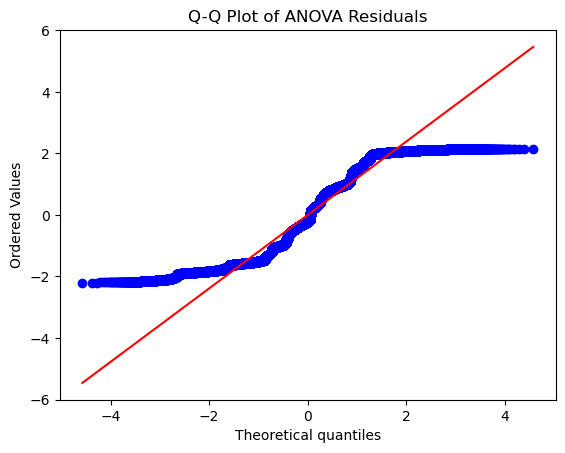

In [9]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of ANOVA Residuals")
plt.show()

The S-curve indicates a platykurtic distribution: the data is more concentrated around the center with lighter tails than a true normal. This is a direct consequence of PCA producing a bounded composite score. For the F-test, we will need to interpret tail-end results cautiously.

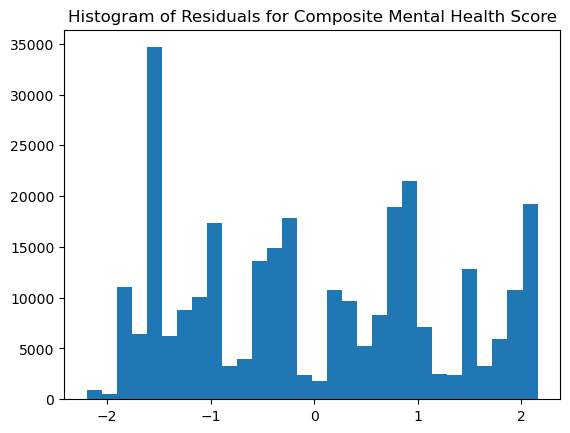

In [10]:
plt.hist(residuals, bins=30)
plt.title("Histogram of Residuals for Composite Mental Health Score")
plt.show()

## Q-Q Plot for Music Valence

In [12]:
model_valence = smf.ols("valence ~ C(season)", data=music).fit()
residuals_valence = model_valence.resid

((array([-3.47337984, -3.22778803, -3.09187317, ...,  3.09187317,
          3.22778803,  3.47337984]),
  array([-1.49235307, -1.49235257, -1.49235257, ...,  0.62772738,
          0.62772741,  0.62772741])),
 (np.float64(0.6434115510416915),
  np.float64(-1.4995385032181273e-15),
  np.float64(0.8781551175014395)))

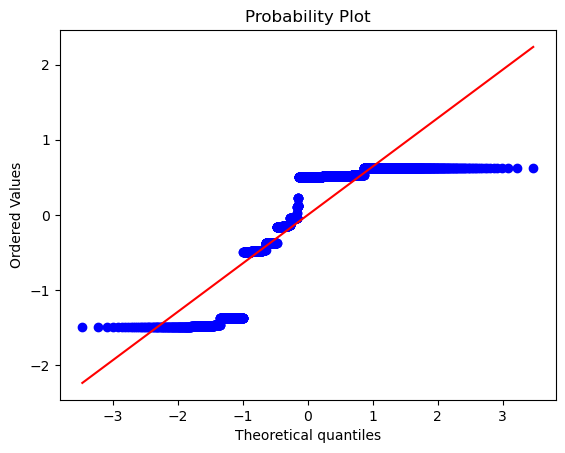

In [13]:
stats.probplot(residuals_valence, dist="norm", plot=plt)

The step-like pattern with hard compression at ±1 reflects near-discrete clustering (tracks rated 0 or 1). This near-discrete clustering reinforces our use for Q-Q plots over the K-S test, which would have hidden the discrete structure (showing only a general deviation from the smooth normal CDF).

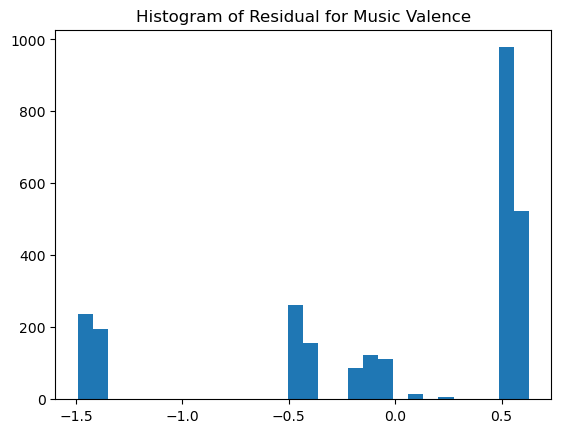

In [11]:
plt.hist(residuals_valence, bins=30)
plt.title("Histogram of Residual for Music Valence")
plt.show()

The clustering distribution suggests that we may have to deviate from our originally pitched F-test, which requires normality. We would either have to add noise to our data to make the music valence more normal, or swtich to a different test that does not require normality like the Kruskal-Wallis test.